<a href="https://colab.research.google.com/github/Ghala-78sh/neural_network_from_scratch/blob/main/MNIST_from_Scrach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [39]:
import os

# Construct the correct path to the CSV file and load it
train_csv_path = os.path.join(path, 'train.csv')
data = pd.read_csv(train_csv_path)
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
import kagglehub
path = kagglehub.dataset_download("animatronbot/mnist-digit-recognizer")

Using Colab cache for faster access to the 'mnist-digit-recognizer' dataset.


In [41]:
# Convert the pandas DataFrame to a NumPy array
data = np.array(data)
m, n = data.shape

# Safely shuffle the NumPy array
np.random.shuffle(data)

# Split into dev and train sets (and transpose so features are in rows)
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

In [42]:
# Normalize the image data to be between 0 and 1
X_train = X_train / 255.0
X_dev = X_dev / 255.0

# Run gradient descent with the correct parameter order: alpha=0.1, iterations=500
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, 0.1, 500)

Iteration:  0
[5 5 8 ... 4 4 4] [9 2 8 ... 0 1 9]
0.09219512195121951
Iteration:  10
[5 2 5 ... 0 5 2] [9 2 8 ... 0 1 9]
0.1546341463414634
Iteration:  20
[5 5 5 ... 0 5 2] [9 2 8 ... 0 1 9]
0.20219512195121953
Iteration:  30
[5 2 5 ... 0 1 6] [9 2 8 ... 0 1 9]
0.27395121951219514
Iteration:  40
[5 2 1 ... 0 1 6] [9 2 8 ... 0 1 9]
0.36404878048780487
Iteration:  50
[5 2 1 ... 0 1 6] [9 2 8 ... 0 1 9]
0.4092682926829268
Iteration:  60
[3 2 1 ... 0 1 6] [9 2 8 ... 0 1 9]
0.4414878048780488
Iteration:  70
[3 2 1 ... 0 1 6] [9 2 8 ... 0 1 9]
0.47048780487804875
Iteration:  80
[3 2 1 ... 0 1 6] [9 2 8 ... 0 1 9]
0.4978048780487805
Iteration:  90
[3 2 1 ... 0 1 4] [9 2 8 ... 0 1 9]
0.5223414634146342
Iteration:  100
[3 2 1 ... 0 1 4] [9 2 8 ... 0 1 9]
0.5460731707317074
Iteration:  110
[3 2 1 ... 0 1 4] [9 2 8 ... 0 1 9]
0.5668780487804878
Iteration:  120
[3 2 1 ... 0 1 4] [9 2 8 ... 0 1 9]
0.5867560975609756
Iteration:  130
[3 2 1 ... 0 1 4] [9 2 8 ... 0 1 9]
0.6058536585365853
Iteration:  

In [43]:
def init_params():
  w1 = np.random.rand(10, 784) - 0.5
  b1 = np.random.rand(10, 1) - 0.5
  w2 = np.random.rand(10, 10) - 0.5
  b2 = np.random.rand(10, 1) - 0.5
  return w1, b1, w2, b2

def ReLU(Z):
  return np.maximum(Z, 0)

def softmax(Z):
  return np.exp(Z) / np.sum(np.exp(Z), axis=0)

def forward_prop(w1, b1, w2, b2, X):
  Z1 = w1.dot(X) + b1
  A1 = ReLU(Z1)
  Z2 = w2.dot(A1) + b2
  A2 = softmax(Z2)
  return Z1, A1, Z2, A2

def one_hot(Y):
  one_hot_Y = np.zeros((Y.size, Y.max() + 1))
  one_hot_Y[np.arange(Y.size), Y] = 1
  one_hot_Y = one_hot_Y.T
  return one_hot_Y

def deriv_ReLU(Z):
  return Z > 0

def back_prop(Z1, A1, Z2, A2, w1, w2, X, Y):
  one_hot_Y = one_hot(Y)
  dZ2 = A2 - one_hot_Y
  dw2 = 1 / m * dZ2.dot(A1.T)
  db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
  dZ1 = w2.T.dot(dZ2) * deriv_ReLU(Z1)
  dw1 = 1 / m * dZ1.dot(X.T)
  db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
  return dw1, db1, dw2, db2

def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
  w1 = w1 - alpha * dw1
  b1 = b1 - alpha * db1
  w2 = w2 - alpha * dw2
  b2 = b2 - alpha * db2
  return w1, b1, w2, b2

In [44]:
def get_predictions(A2):
  return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
  print(predictions, Y)
  return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
  w1, b1, w2, b2 = init_params()
  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_prop(w1, b1, w2, b2, X)
    dw1, db1, dw2, db2 = back_prop(Z1, A1, Z2, A2, w1, w2, X, Y)
    w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha)
    if i % 10 == 0:
      print("Iteration: ", i)
      predictions = get_predictions(A2)
      print(get_accuracy(predictions, Y))
  return w1, b1, w2, b2

In [45]:
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, 0.1, 500)

Iteration:  0
[2 7 9 ... 8 3 2] [9 2 8 ... 0 1 9]
0.04214634146341464
Iteration:  10
[2 7 0 ... 5 3 2] [9 2 8 ... 0 1 9]
0.12268292682926829
Iteration:  20
[3 2 0 ... 0 3 2] [9 2 8 ... 0 1 9]
0.2550731707317073
Iteration:  30
[3 2 8 ... 0 1 2] [9 2 8 ... 0 1 9]
0.3625121951219512
Iteration:  40
[6 2 8 ... 0 1 7] [9 2 8 ... 0 1 9]
0.4368292682926829
Iteration:  50
[6 2 8 ... 0 1 7] [9 2 8 ... 0 1 9]
0.4851951219512195
Iteration:  60
[2 2 8 ... 0 1 7] [9 2 8 ... 0 1 9]
0.5196829268292683
Iteration:  70
[2 2 8 ... 0 1 7] [9 2 8 ... 0 1 9]
0.5457317073170732
Iteration:  80
[9 2 8 ... 0 1 7] [9 2 8 ... 0 1 9]
0.5703414634146341
Iteration:  90
[9 2 8 ... 0 1 9] [9 2 8 ... 0 1 9]
0.5896585365853658
Iteration:  100
[9 2 8 ... 0 1 9] [9 2 8 ... 0 1 9]
0.6077317073170732
Iteration:  110
[9 2 8 ... 0 1 9] [9 2 8 ... 0 1 9]
0.6251219512195122
Iteration:  120
[9 2 8 ... 0 1 9] [9 2 8 ... 0 1 9]
0.6420975609756098
Iteration:  130
[9 2 8 ... 0 1 9] [9 2 8 ... 0 1 9]
0.6569756097560976
Iteration:  140

Prediction: 2
Label: 2


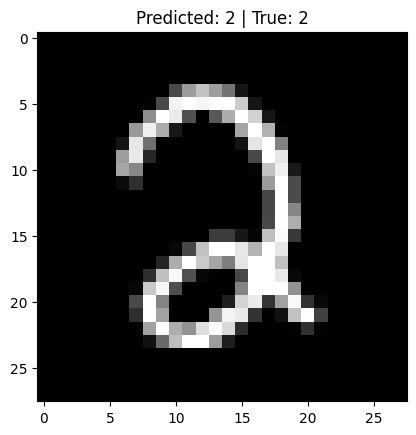

In [47]:
def make_predictions(X, w1, b1, w2, b2):
    _, _, _, A2 = forward_prop(w1, b1, w2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, w1, b1, w2, b2):
    # Extract a single image as a column vector from X_dev
    current_image = X_dev[:, index:index+1]
    prediction = make_predictions(current_image, w1, b1, w2, b2)
    label = Y_dev[index]
    print(f"Prediction: {prediction[0]}")
    print(f"Label: {label}")

    # Reshape the 784 pixels back to 28x28 and scale back to [0, 255] for plotting
    pixel_matrix = current_image.reshape((28, 28)) * 255.0
    plt.gray()
    plt.imshow(pixel_matrix, interpolation='nearest')
    plt.title(f"Predicted: {prediction[0]} | True: {label}")
    plt.show()

# Visualize prediction for the first image in the development set
test_prediction(184, w1, b1, w2, b2)